In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
energy_df = pd.read_csv("ENB2012_data.csv")
energy_df.head(10)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
5,0.90,563.5,318.5,122.50,7.0,3,0.0,0,21.46,25.38
6,0.90,563.5,318.5,122.50,7.0,4,0.0,0,20.71,25.16
7,0.90,563.5,318.5,122.50,7.0,5,0.0,0,19.68,29.60
8,0.86,588.0,294.0,147.00,7.0,2,0.0,0,19.50,27.30
9,0.86,588.0,294.0,147.00,7.0,3,0.0,0,19.95,21.97


In [3]:
energy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


In [4]:
feature = ["X5", "X6", "X7", "X8"]
print("Categorical Features")
for i in feature:
    print(f"{i}: {energy_df[i].unique().tolist()}")

Categorical Features
X5: [7.0, 3.5]
X6: [2, 3, 4, 5]
X7: [0.0, 0.1, 0.25, 0.4]
X8: [0, 1, 2, 3, 4, 5]


In [5]:
# Identify feature columns (X1-X8)
feature_cols = [c for c in energy_df.columns if c.startswith('X')]

# Calculate correlations between features and target variables Y1, Y2
target_corr = energy_df[feature_cols + ['Y1', 'Y2']].corr()[['Y1', 'Y2']].drop(['Y1', 'Y2'])

print("Correlation of Features with Y1 and Y2:")
print(target_corr.round(3))

Correlation of Features with Y1 and Y2:
       Y1     Y2
X1  0.622  0.634
X2 -0.658 -0.673
X3  0.456  0.427
X4 -0.862 -0.863
X5  0.889  0.896
X6 -0.003  0.014
X7  0.270  0.208
X8  0.087  0.051


## **1. Understanding the Target Variable(s)**

### **1.1. Descriptive Statistics**

In [6]:
energy_df[['Y1', 'Y2']].describe()

,Y1,Y2
count,768.000000,768.000000
mean,22.307201,24.587760
std,10.090196,9.513306
min,6.010000,10.900000
25%,12.992500,15.620000
50%,18.950000,22.080000
75%,31.667500,33.132500
max,43.100000,48.030000


### **1.2. Distribution Visualization (Histogram + KDE)**

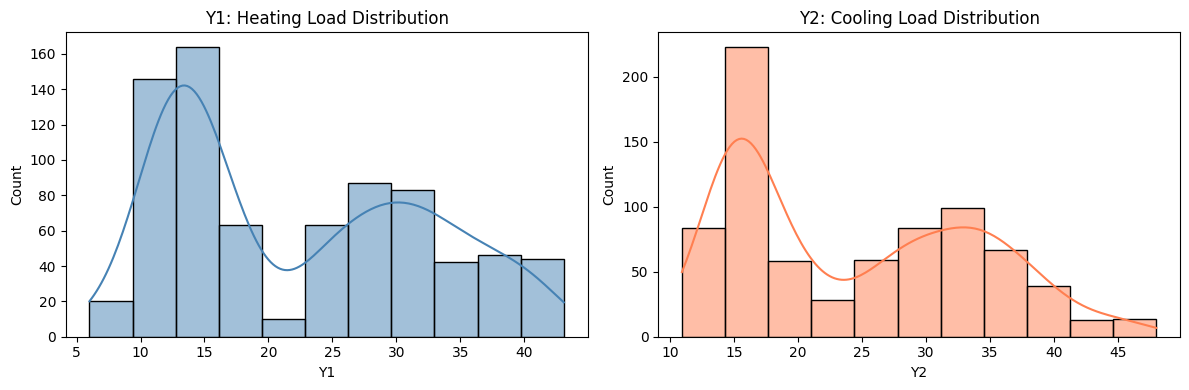

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(energy_df['Y1'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Y1: Heating Load Distribution')
sns.histplot(energy_df['Y2'], kde=True, ax=axes[1], color='coral')
axes[1].set_title('Y2: Cooling Load Distribution')
plt.tight_layout()
plt.show()

- On the left, you see heating load. On the right, cooling load. Think of these as how much energy a building needs to stay comfortable. The taller bars mean more buildings fall into that range.
- What stands out here is that most buildings cluster around certain values. For heating, a lot sit between 10 and 15. For cooling, the sweet spot is around 15. But there are also buildings that need much more energy on both ends. This tells us buildings are not all the same. Some are efficient. Some really are not.

### **1.3. Target (Y1 and Y2) Correlation**

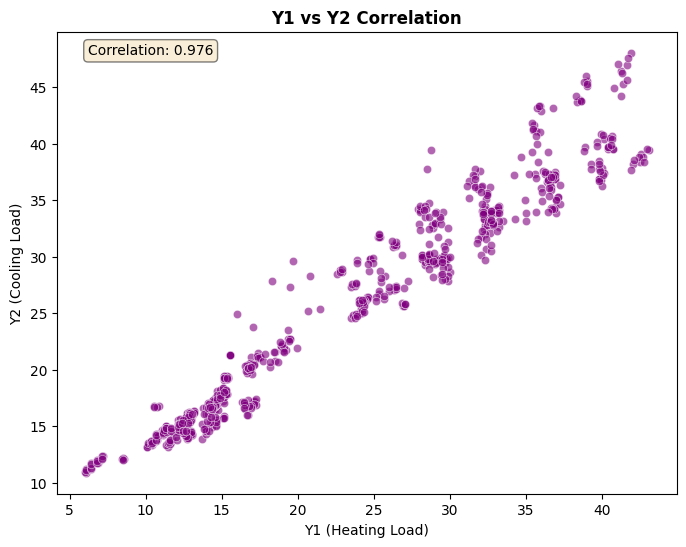

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x=energy_df['Y1'], y=energy_df['Y2'], alpha=0.6, c='purple', edgecolors='white', linewidth=0.5, ax=ax)
ax.set_xlabel('Y1 (Heating Load)')
ax.set_ylabel('Y2 (Cooling Load)')
ax.set_title('Y1 vs Y2 Correlation', fontsize=12, fontweight='bold')
correlation = energy_df['Y1'].corr(energy_df['Y2'])
ax.text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=ax.transAxes,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.show()

- Each dot is one building. The line going up from left to right shows something important. Buildings that need more heating also tend to need more cooling. The number in the corner, 0.976, is really high. In plain terms, these two things move together almost perfectly.
- This makes sense when you think about it. A building that loses heat easily in winter probably lets heat in easily during summer too. The same features that make heating hard also make cooling hard.

## **2. Univariate Feature Analysis**

### **2.1. Descriptive Statistics per Feature**

In [9]:
energy_df.describe().round(2)

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,0.76,671.71,318.50,176.60,5.25,3.50,0.23,2.81,22.31,24.59
std,0.11,88.09,43.63,45.17,1.75,1.12,0.13,1.55,10.09,9.51
min,0.62,514.50,245.00,110.25,3.50,2.00,0.00,0.00,6.01,10.90
25%,0.68,606.38,294.00,140.88,3.50,2.75,0.10,1.75,12.99,15.62
50%,0.75,673.75,318.50,183.75,5.25,3.50,0.25,3.00,18.95,22.08
75%,0.83,741.12,343.00,220.50,7.00,4.25,0.40,4.00,31.67,33.13
max,0.98,808.50,416.50,220.50,7.00,5.00,0.40,5.00,43.10,48.03


### **2.2. Skewness and Kurtosis**

In [10]:
features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']
skew_kurt = pd.DataFrame({
    'Skewness': [energy_df[f].skew() for f in features],
    'Kurtosis': [energy_df[f].kurtosis() for f in features]
}, index=features)
print(skew_kurt.round(3))

    Skewness  Kurtosis
X1     0.496    -0.707
X2    -0.125    -1.059
X3     0.533     0.117
X4    -0.163    -1.777
X5     0.000    -2.005
X6     0.000    -1.361
X7    -0.060    -1.328
X8    -0.089    -1.149


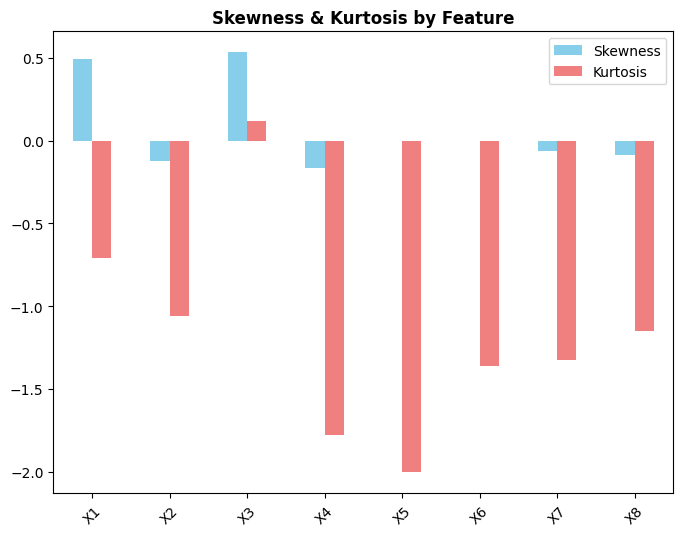

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
skew_kurt = pd.DataFrame({
    'Skewness': energy_df[features].skew(),
    'Kurtosis': energy_df[features].kurtosis()
})
skew_kurt.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral'])
ax.set_title('Skewness & Kurtosis by Feature', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.show()

- The blue bars show skewness. The red bars show kurtosis. Without getting too deep, skewness tells us if data leans left or right. Kurtosis tells us about extreme values.
- What matters here is that most red bars point down. This suggests the data has some unusual patterns. Not everything fits a neat bell curve. There are quirks worth paying attention to.

### **2.3. Box Plots for Outlier Detection**

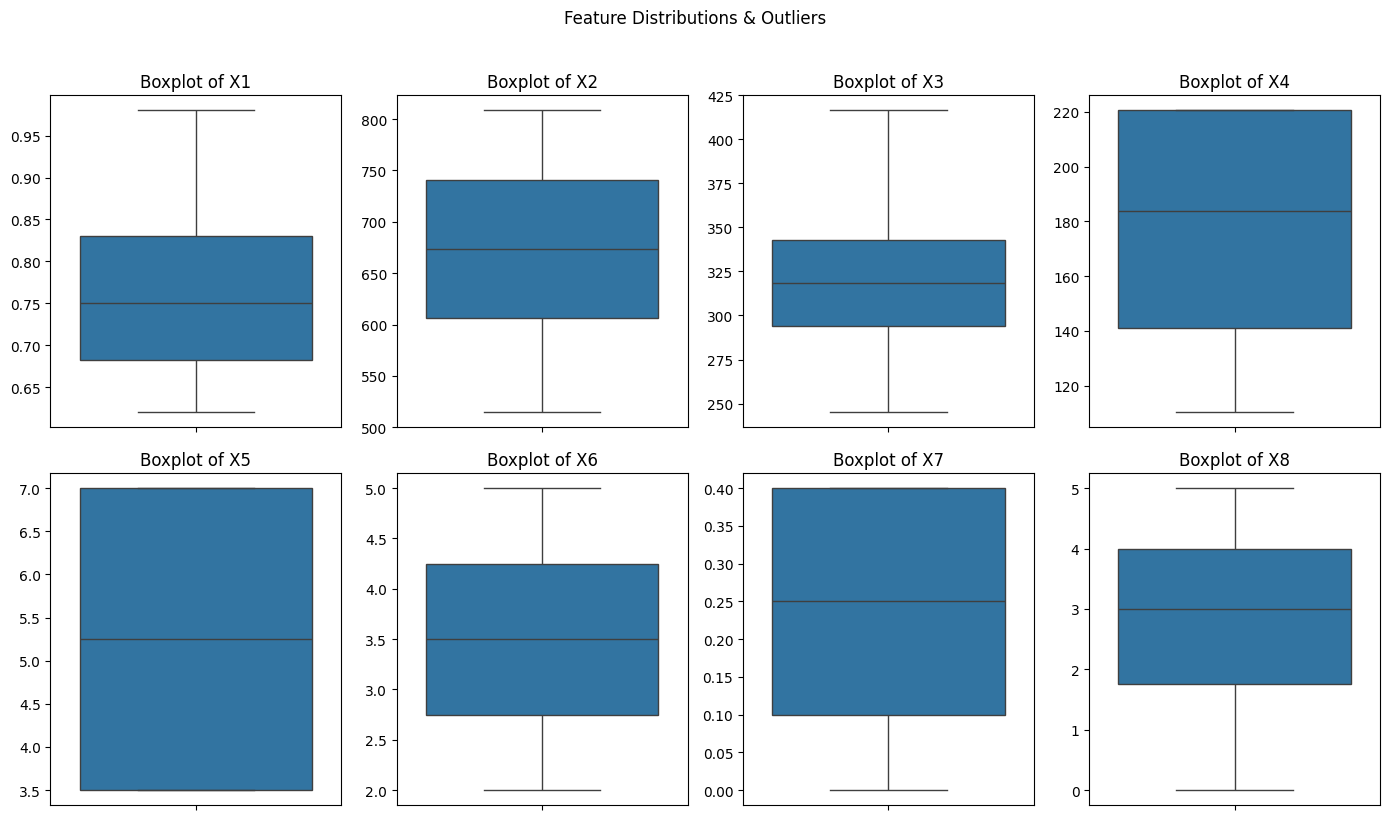

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=energy_df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

plt.suptitle('Feature Distributions & Outliers', y=1.02)
plt.tight_layout()
plt.show()

- Each box represents one feature, labeled X1 through X8. The box itself shows where most values sit. The lines sticking out show the full range.
- Some boxes are tall. Some are short. Tall boxes mean more variety in that feature. Short boxes mean buildings are more similar. X5 and X4 have particularly tall boxes. Whatever these measure, buildings differ a lot on them.

## **3. Bivariate Analysis (Feature-Target Relationships)**

### **3.1. Scatter Plots: Key Features vs Y1**

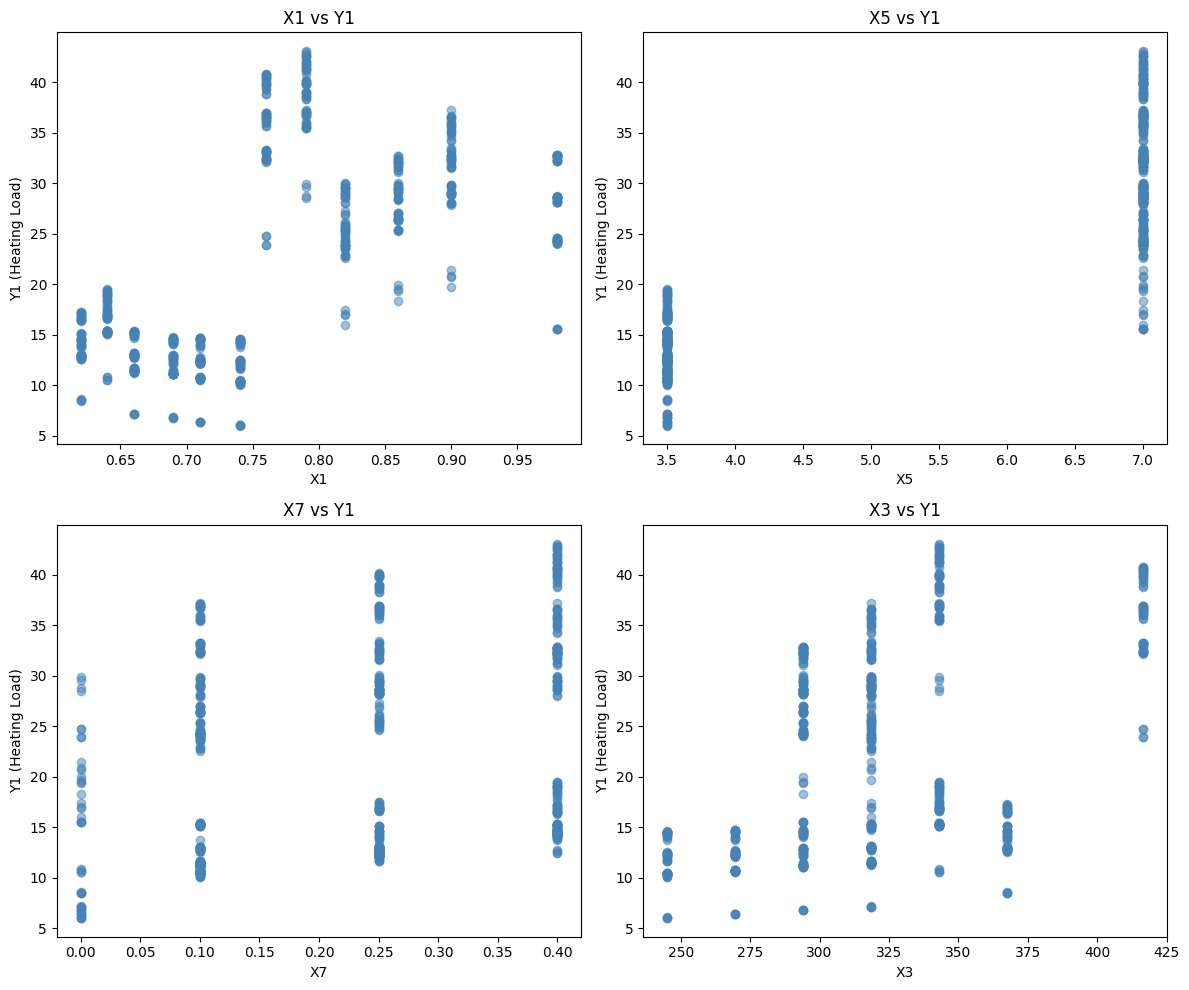

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
key_features = ['X1', 'X5', 'X7', 'X3']
for i, feat in enumerate(key_features):
    ax = axes[i//2, i%2]
    ax.scatter(energy_df[feat], energy_df['Y1'], alpha=0.5, c='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('Y1 (Heating Load)')
    ax.set_title(f'{feat} vs Y1')
plt.tight_layout()
plt.show()

- These four scatter plots show how different features relate to heating needs. The patterns here are not as clean as the heating versus cooling chart earlier.
- Some show weak connections. Some show almost nothing.
This actually makes sense. Heating load depends on many things at once. No single feature tells the whole story. You need to look at the combination.

### **3.2. Correlation with Targets - Bar plot**

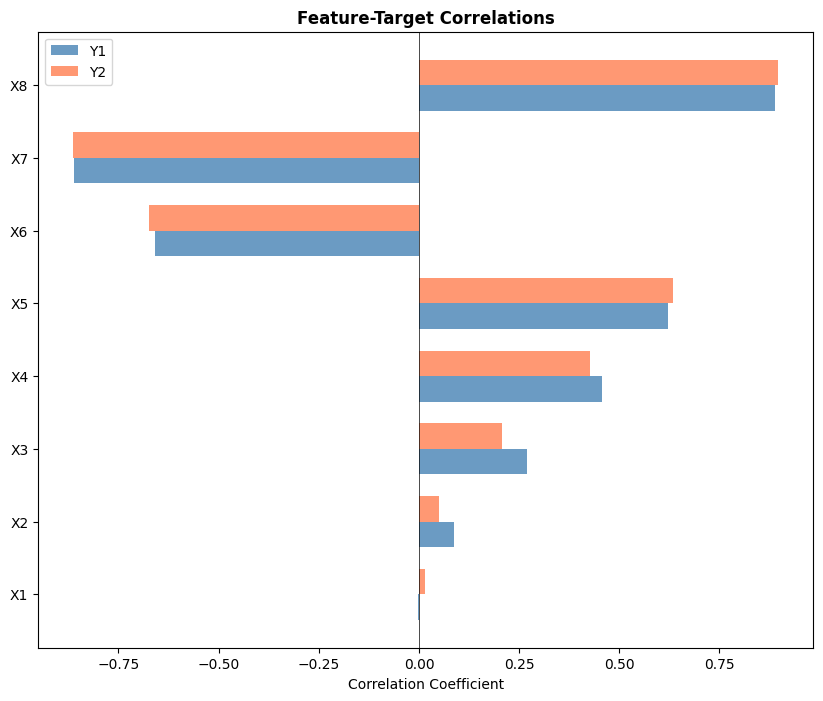

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
correlations_y1 = energy_df[features].corrwith(energy_df['Y1']).sort_values(key=abs, ascending=True)
correlations_y2 = energy_df[features].corrwith(energy_df['Y2']).sort_values(key=abs, ascending=True)

x_pos = np.arange(len(features))
width = 0.35

ax.barh(x_pos - width/2, correlations_y1, width, label='Y1', color='steelblue', alpha=0.8)
ax.barh(x_pos + width/2, correlations_y2, width, label='Y2', color='coral', alpha=0.8)
ax.set_yticks(x_pos)
ax.set_yticklabels(features)
ax.set_xlabel('Correlation Coefficient')
ax.set_title('Feature-Target Correlations', fontsize=12, fontweight='bold')
ax.legend()
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.show()

This shows connections to heating and cooling.
- Look at X8 at the top. It has long bars stretching to the right. This means it has a strong link. When X8 goes up, energy use goes up.
- X7 has long bars to the left. This means the opposite. When X7 goes up, energy use goes down. X1 at the bottom has almost no bar. It does not really affect energy use much.

### **3.3. Feature Importance (absolute correlation)**

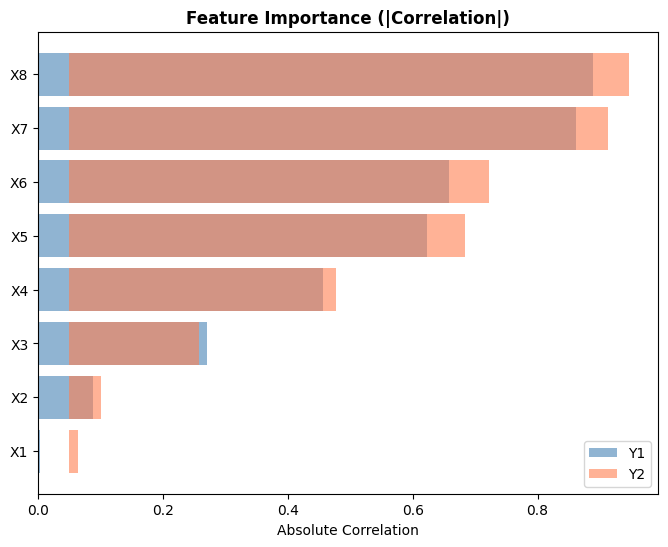

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
importance_y1 = energy_df[features].corrwith(energy_df['Y1']).abs().sort_values(ascending=True)
importance_y2 = energy_df[features].corrwith(energy_df['Y2']).abs().sort_values(ascending=True)
ax.barh(range(len(features)), importance_y1, alpha=0.6, label='Y1', color='steelblue')
ax.barh(range(len(features)), importance_y2, alpha=0.6, label='Y2', color='coral', left=0.05)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features)
ax.set_xlabel('Absolute Correlation')
ax.set_title('Feature Importance (|Correlation|)', fontsize=12, fontweight='bold')
ax.legend()
plt.show()

This chart simplifies this view. It just measures strength. It does not matter if the link is positive or negative. X8 and X7 are still the most important. They dominate the list. X1 is still the weakest. This tells us where to focus attention. If you want to change energy use, look at X8 and X7 first.

## **4. Multivariate Analysis & Feature Interactions**

### **4.1. Correlation Heatmap**

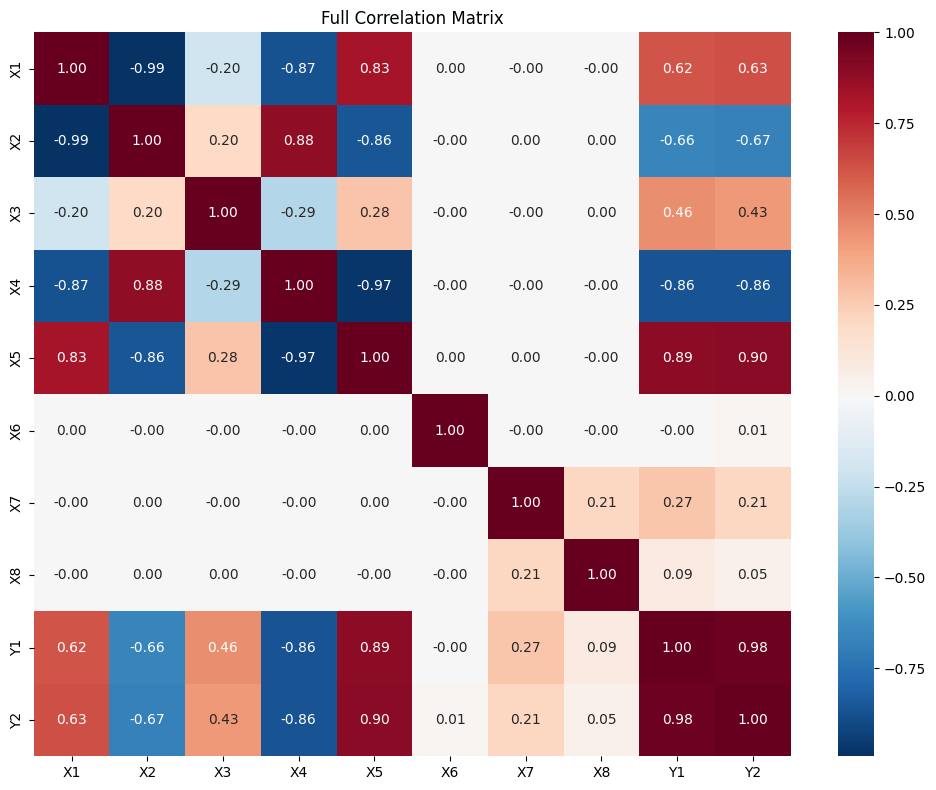

In [16]:
plt.figure(figsize=(10, 8))
sns.heatmap(energy_df.corr(), annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Full Correlation Matrix')
plt.tight_layout()
plt.show()

- These show relationships between every pair of variables. Dark red means they move together. Dark blue means they move in opposite directions. White means no connection.
- Look at the bottom right corner. Y1 and Y2 are dark red. We already knew they move together. Also look at X1 and X2. They are dark blue. When one goes up, the other goes down almost perfectly. They are basically opposites. This suggests they might be measuring similar things in different ways.

### **4.2. Pearson Correlation Heatmap (all variables)**

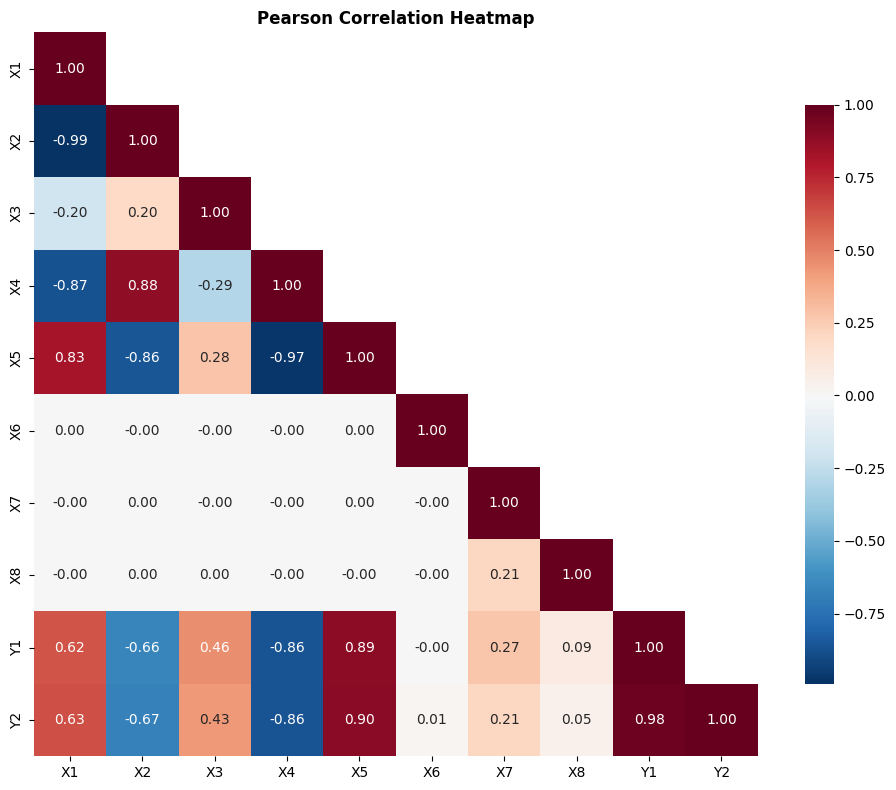

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = energy_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Pearson Correlation Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### **4.3. Pairwise Scatter Matrix (subset)**

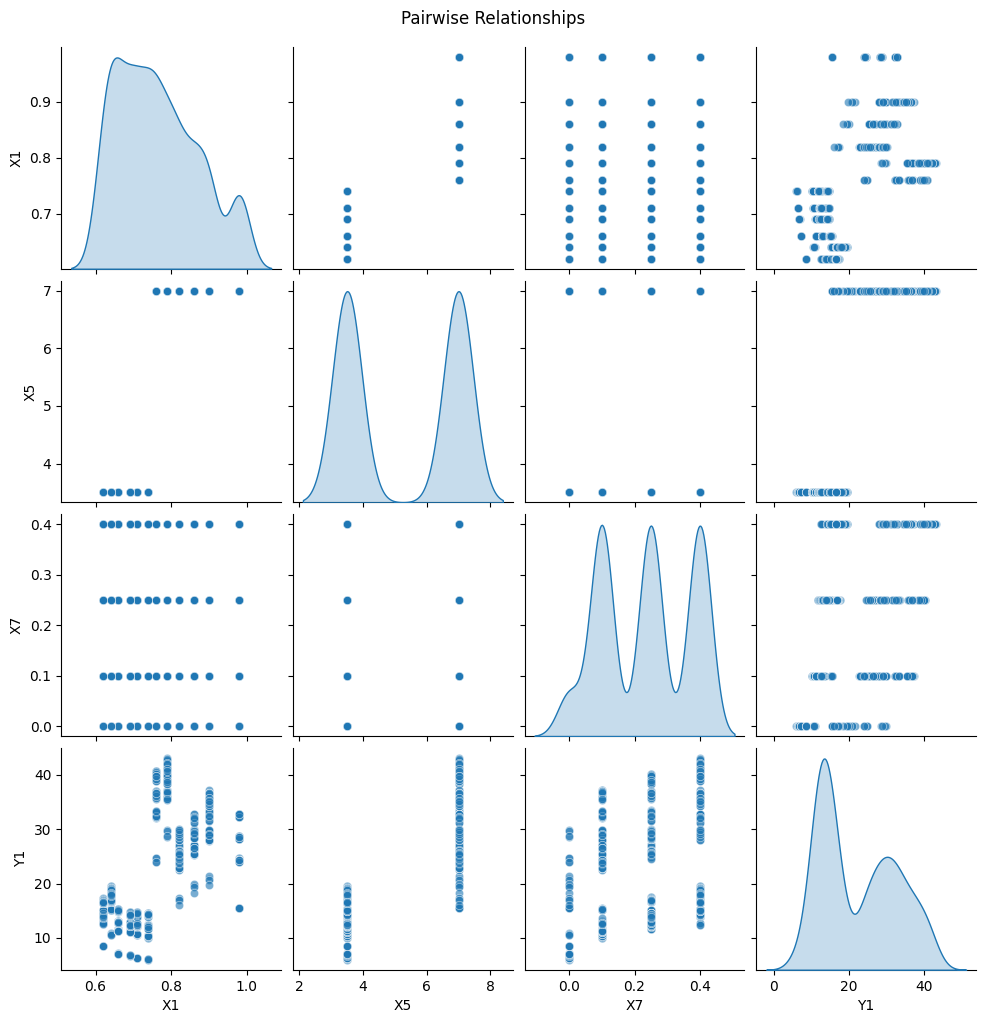

In [18]:
subset = energy_df[['X1', 'X5', 'X7', 'Y1']]
sns.pairplot(subset, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairwise Relationships', y=1.02)
plt.show()

- The ones on the diagonal show the shape of the data for each feature. Some look like smooth hills. X5 has two humps instead of one. This suggests there might be two types of buildings in the data.
- The other plots show dots scattered around. Some form clear lines. Others look more random. X7 shows distinct lines of dots. This means it only takes certain specific values. It is not a smooth range.

### **4.4. PCA for Dimensionality Insight**

In [19]:
X = energy_df[['X1', 'X2', 'X3', 'X4', 'X5', 'X7']]
X_scaled = StandardScaler().fit_transform(X)
pca = PCA()
pca.fit(X_scaled)
print("PCA EXPLAINED VARIANCE")
print(f"Explained variance ratio: {pca.explained_variance_ratio_.round(3)}")
print(f"Cumulative variance: {pca.explained_variance_ratio_.cumsum().round(3)}")

PCA EXPLAINED VARIANCE
Explained variance ratio: [0.617 0.207 0.167 0.009 0.001 0.   ]
Cumulative variance: [0.617 0.824 0.99  0.999 1.    1.   ]


## **5. Outlier Detection**

### **5.1. IQR Method**

In [20]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[column] < Q1 - 1.5*IQR) | (data[column] > Q3 + 1.5*IQR)]
    return len(outliers)

for col in ['Y1', 'Y2', 'X1', 'X7']:
    print(f"{col}: {detect_outliers_iqr(energy_df, col)} outliers")

Y1: 0 outliers
Y2: 0 outliers
X1: 0 outliers
X7: 0 outliers


### **5.2. Z-Score Method**

In [21]:
z_scores = np.abs(stats.zscore(energy_df[['Y1', 'Y2']]))
outliers_z = (z_scores > 3).sum(axis=0)
print(f"Y1: {outliers_z[0]}, Y2: {outliers_z[1]}")

Y1: 0, Y2: 0


### **5.3. Isolation Forest**

In [22]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
outliers = iso_forest.fit_predict(energy_df[['X1', 'X5', 'X7', 'Y1']])
print(f"Detected {sum(outliers == -1)} outliers ({sum(outliers == -1)/len(outliers)*100:.1f}%)")

Detected 39 outliers (5.1%)


## **6. Missing Value Analysis**

### **6.1. Missing Value Summary**

In [23]:
missing = energy_df.isnull().sum()
missing_pct = (energy_df.isnull().sum() / len(energy_df) * 100).round(2)
missing_energy_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_energy_df[missing_energy_df['Count'] > 0] if missing.sum() > 0 else "No missing values found")

No missing values found


### **6.2. Missing by Feature (comprehensive check)**

In [24]:
print(f"Total missing in dataset: {energy_df.isnull().sum().sum()}")
print(f"Rows with any missing: {energy_df.isnull().any(axis=1).sum()}")

Total missing in dataset: 0
Rows with any missing: 0


## **7. Multicollinearity Assessment**

### **7.1. Variance Inflation Factor (VIF)**

In [25]:
X = energy_df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8']]
vif_data = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif_data.sort_values('VIF', ascending=False))

  Feature         VIF
1      X2         inf
2      X3         inf
3      X4         inf
0      X1  168.948751
4      X5  134.035782
5      X6   10.796725
7      X8    4.496320
6      X7    4.293656


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


### **7.2. High Correlation Pairs**

In [26]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(corr_matrix.columns[i], corr_matrix.columns[j], upper.iloc[i, j])
             for i in range(len(upper)) for j in range(i+1, len(upper)) if upper.iloc[i, j] > 0.8]
print(f"HIGH CORRELATION PAIRS (> 0.8)")
for feat1, feat2, corr in high_corr:
    print(f"{feat1} - {feat2}: {corr:.3f}")

HIGH CORRELATION PAIRS (> 0.8)
X1 - X2: 0.992
X1 - X4: 0.869
X1 - X5: 0.828
X2 - X4: 0.881
X2 - X5: 0.858
X4 - X5: 0.973


### **7.3. Condition Number**

In [27]:
eigenvalues = np.linalg.eigvals(X.corr())
cond_number = np.sqrt(eigenvalues.max() / eigenvalues.min())
print(f"Condition Number: {cond_number:.2f} (> 30 indicates multicollinearity)")

Condition Number: 129408812.08 (> 30 indicates multicollinearity)


## **8. Categorical Feature Analysis**

### **8.1. Value Counts for Categoricals**

In [28]:
print("CATEGORICAL FEATURE DISTRIBUTIONS")
print("X6 (Orientation):")
print(energy_df['X6'].value_counts().sort_index())
print("\nX8 (Glazing Distribution):")
print(energy_df['X8'].value_counts().sort_index())

CATEGORICAL FEATURE DISTRIBUTIONS
X6 (Orientation):
X6
2    192
3    192
4    192
5    192
Name: count, dtype: int64

X8 (Glazing Distribution):
X8
0     48
1    144
2    144
3    144
4    144
5    144
Name: count, dtype: int64


### **8.2. Target Mean by Category**

In [29]:
print("Y1 MEAN BY CATEGORY")
print("By Orientation (X6):")
print(energy_df.groupby('X6')['Y1'].mean().round(2))
print("\nBy Glazing Distribution (X8):")
print(energy_df.groupby('X8')['Y1'].mean().round(2))

Y1 MEAN BY CATEGORY
By Orientation (X6):
X6
2    22.31
3    22.38
4    22.26
5    22.28
Name: Y1, dtype: float64

By Glazing Distribution (X8):
X8
0    14.29
1    23.03
2    22.93
3    22.68
4    22.89
5    22.68
Name: Y1, dtype: float64


### **8.3. Box Plots by Category**

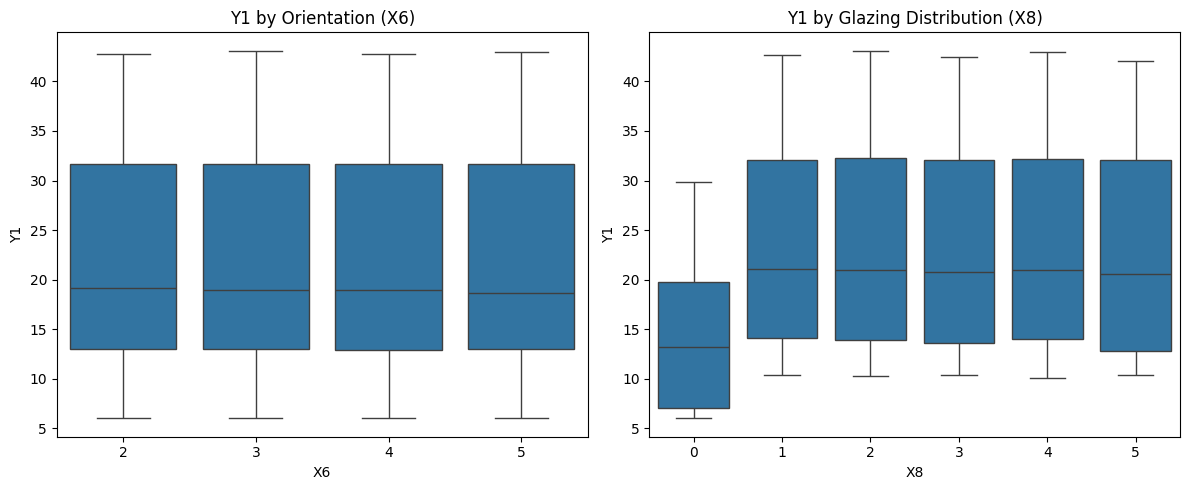

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(x='X6', y='Y1', data=energy_df, ax=axes[0])
axes[0].set_title('Y1 by Orientation (X6)')
sns.boxplot(x='X8', y='Y1', data=energy_df, ax=axes[1])
axes[1].set_title('Y1 by Glazing Distribution (X8)')
plt.tight_layout()
plt.show()

## **9. Data Quality Assessment**

### **9.1. Duplicate Detection**

In [31]:
duplicates = energy_df.duplicated().sum()
print("DATA QUALITY CHECKS")
print(f"Duplicate rows: {duplicates} ({duplicates/len(energy_df)*100:.2f}%)")

DATA QUALITY CHECKS
Duplicate rows: 0 (0.00%)


### **9.2. Range Validation (based on domain knowledge)**

In [32]:
print(f"RANGE VALIDATION")
print(f"X1 (Compactness): {energy_df['X1'].min():.2f} - {energy_df['X1'].max():.2f} [expected: 0.6-1.0]")
print(f"X6 (Orientation): {energy_df['X6'].min():.0f} - {energy_df['X6'].max():.0f} [expected: 2-5]")
print(f"X7 (Glazing Area): {energy_df['X7'].min():.2f} - {energy_df['X7'].max():.2f} [expected: 0.0-0.4]")
print(f"X8 (Glazing Dist): {energy_df['X8'].min():.0f} - {energy_df['X8'].max():.0f} [expected: 0-5]")

RANGE VALIDATION
X1 (Compactness): 0.62 - 0.98 [expected: 0.6-1.0]
X6 (Orientation): 2 - 5 [expected: 2-5]
X7 (Glazing Area): 0.00 - 0.40 [expected: 0.0-0.4]
X8 (Glazing Dist): 0 - 5 [expected: 0-5]


### **9.3. Logical Consistency Checks**

In [33]:
print(f"LOGICAL CONSISTENCY")
# Surface area should be larger than wall area
inconsistent = (energy_df['X2'] <= energy_df['X3']).sum()
print(f"Rows where Surface Area ≤ Wall Area: {inconsistent} (should be 0)")

LOGICAL CONSISTENCY
Rows where Surface Area ≤ Wall Area: 0 (should be 0)


### **9.4. Check for impossible combinations**

In [34]:
invalid_glazing = ((energy_df['X7'] == 0) & (energy_df['X8'] > 0)).sum()
print(f"Rows with 0 glazing but distribution > 0: {invalid_glazing} (should be 0)")

Rows with 0 glazing but distribution > 0: 0 (should be 0)


### **9.5. Overall quality score**

In [35]:
issues = duplicates + inconsistent + invalid_glazing
print(f"Total data quality issues: {issues} ({issues/len(energy_df)*100:.2f}%)")

Total data quality issues: 0 (0.00%)
